# 21d — our estimator vs Gregor's lmfit: observables, timing, and is the surrogate gradient viable?

**Series 21 (supervised).** Three parts:
1. **Forward-value comparison** — on the *same simulated scans*, extract (FWHM, sigma_fit) with our
   fit and with Gregor's lmfit (binned spectrum, Voigt+constant, 2.2 MHz bins, >=3-counts filter),
   and compare both against the REAL data per experiment.
2. **Timing** — head-to-head per-scan cost (ours vs lmfit).
3. **Surrogate-gradient viability** — compute `dFWHM/dgamma` (and `d sigma/dgamma`) two ways: our
   implicit-diff vs finite-difference through lmfit, over a gamma grid and across count regimes.
   Viability criterion: the ratio ours/lmfit must be **positive, ~constant, within ~+-20%** across the
   operating range; it **fails** where the ratio flips sign or drifts hard (expected at low count).

Motivation: the sigma channel is the mu channel (mu ~ identified via sigma ~ f(1/sqrt(n))), and the
21c pre-check showed our sim sigma / real sigma = 0.24-1.08 (worst ~4x too small at high T). If lmfit
matches the real observable, adopting it changes the mu channel — and the surrogate test tells us
whether we can keep our implicit-diff gradient while doing so.


In [1]:
import math, time, os, sys
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float32)

for _p in [os.getcwd(), os.path.join(os.getcwd(), '..'), os.path.join(os.getcwd(), '..', '..')]:
    if os.path.isdir(os.path.join(_p, 'src')):
        sys.path.insert(0, _p)
        REPO_ROOT = _p
        break
os.chdir(REPO_ROOT)

from src.fitting import nll, fwhm_from_theta, fit_profile
from src.samplers import draw_fixed_noise, build_photons
from src.implicit import compute_fwhm_and_dgamma

print('Imports OK')

Imports OK


In [2]:
# ============================================================
# EXPERIMENTS — true values from Gregor's fits (identical to 17f/16-series) + real data file
# ============================================================
EXPERIMENTS = [
    dict(name='1nW Trans05',  power='1nW', mu_true=9.393, sigma_prop=2.576, lam=2.232, gamma_true=8.5, n_target=61, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans05.txt'),
    dict(name='1nW Trans10',  power='1nW', mu_true=12.372, sigma_prop=3.445, lam=2.122, gamma_true=8.5, n_target=358, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans10.txt'),
    dict(name='1nW Trans20',  power='1nW', mu_true=17.316, sigma_prop=4.141, lam=2.286, gamma_true=8.5, n_target=1138, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans20.txt'),
    dict(name='1nW Trans40',  power='1nW', mu_true=38.405, sigma_prop=7.198, lam=2.351, gamma_true=8.5, n_target=2428, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans40.txt'),
    dict(name='1nW Trans60',  power='1nW', mu_true=61.374, sigma_prop=9.851, lam=2.593, gamma_true=8.5, n_target=2424, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans60.txt'),
    dict(name='1nW Trans80',  power='1nW', mu_true=79.365, sigma_prop=12.627, lam=2.758, gamma_true=8.5, n_target=2487, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans80.txt'),
    dict(name='1nW Trans100',  power='1nW', mu_true=70.817, sigma_prop=17.221, lam=2.636, gamma_true=8.5, n_target=2455, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans100.txt'),
    dict(name='3nW Trans05',  power='3nW', mu_true=13.204, sigma_prop=3.724, lam=2.186, gamma_true=14.1, n_target=252, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans05.txt'),
    dict(name='3nW Trans10',  power='3nW', mu_true=24.476, sigma_prop=5.639, lam=2.158, gamma_true=14.1, n_target=1572, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans10.txt'),
    dict(name='3nW Trans20',  power='3nW', mu_true=34.279, sigma_prop=8.319, lam=2.264, gamma_true=14.1, n_target=2171, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans20.txt'),
    dict(name='3nW Trans40',  power='3nW', mu_true=84.892, sigma_prop=24.013, lam=2.475, gamma_true=14.1, n_target=3742, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans40.txt'),
    dict(name='3nW Trans60',  power='3nW', mu_true=103.203, sigma_prop=23.95, lam=2.741, gamma_true=14.1, n_target=2541, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans60.txt'),
    dict(name='3nW Trans80',  power='3nW', mu_true=137.537, sigma_prop=32.107, lam=2.911, gamma_true=14.1, n_target=2508, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans80.txt'),
    dict(name='3nW Trans100',  power='3nW', mu_true=175.707, sigma_prop=40.975, lam=3.087, gamma_true=14.1, n_target=2516, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans100.txt'),
]

# ---- QUICK TEST: uncomment one of these slices ----
# EXPERIMENTS = EXPERIMENTS[:3]                                        # first 3
# EXPERIMENTS = [e for e in EXPERIMENTS if e['name'] in
#                ('1nW Trans80', '3nW Trans80', '3nW Trans100')]      # the hard ones

print(f'{len(EXPERIMENTS)} experiments configured')


14 experiments configured


In [3]:
# ============================================================
# 21d CONFIG + lmfit extractor
# ============================================================
N_SIM   = 40         # sim scans per experiment (observable comparison)
BIN_WIDTH = 2.2      # MHz (paper)
WINDOW    = 75.0     # MHz detection window
MIN_COUNTS = 3       # paper: reject scan unless a bin has >=3 counts
GAMMAS  = [4.0, 6.0, 8.5, 12.0, 16.0]   # gamma grid for the surrogate test
D_DRAWS = 5          # draws averaged per (exp, gamma)
FD_H    = 0.5        # MHz central-difference step through lmfit
TIMING_K = 30        # scans for the timing benchmark

SMOKE = os.environ.get('NB_SMOKE') == '1'
if SMOKE:
    N_SIM, D_DRAWS, TIMING_K = 6, 2, 5
    GAMMAS = [6.0, 8.5]
    EXPERIMENTS = EXPERIMENTS[:3]
    print('*** SMOKE RUN ***')

import numpy as np
from src import fitting_lmfit as FL

def lmfit_extract(photons_np, bin_width=BIN_WIDTH, window=WINDOW):
    """Gregor's estimator: bin the scan, least-squares fit a Voigt+constant, return (FWHM, stderr)."""
    lo, hi = -window / 2.0, window / 2.0
    edges = np.arange(lo, hi + bin_width, bin_width)
    counts, edges = np.histogram(photons_np, bins=edges)
    if counts.size == 0 or counts.max() < MIN_COUNTS:
        return None, None
    x = 0.5 * (edges[:-1] + edges[1:])
    m = FL.voigt
    p = m.make_params()
    p['amplitude'].set(value=max(float(counts.sum()), 1.0), min=0.0)
    p['center'].set(value=float(x[int(np.argmax(counts))]), min=lo, max=hi)
    p['sigma'].set(value=3.0, min=0.05, max=50.0)
    p['gamma'].set(value=3.0, min=0.05, max=100.0)
    p['c'].set(value=float(np.median(counts)), min=0.0)
    try:
        out = m.fit(counts, p, x=x)
    except Exception:
        return None, None
    fw = out.params['fwhm'].value
    se = out.params['fwhm'].stderr
    fw = float(fw) if fw is not None and np.isfinite(fw) else None
    se = float(se) if se is not None and np.isfinite(se) else None
    return fw, se

def make_scan(gamma, mu, sig, lam, rng):
    u, b, n = draw_fixed_noise(mu, sig, lam, rng)
    ph = build_photons(torch.tensor(float(gamma)), torch.as_tensor(u, dtype=torch.float32),
                       torch.as_tensor(b, dtype=torch.float32))
    return u, b, ph

print('21d config + lmfit extractor ready')


21d config + lmfit extractor ready


In [4]:
# ============================================================
# Fixed helpers (identical to the 16-series) + parallel machinery
# ============================================================
def _fit_fn(ph):
    return fit_profile(ph, n_iters=80, model='lorentzian', uniform_bg=False)

def _fwhm_fn(th):
    return fwhm_from_theta(th, model='lorentzian')

def _nll_fn(th, ph):
    return nll(th, ph, model='lorentzian', uniform_bg=False)

def kde_scores(sim_f, sim_s, sim_n, sim_df, sim_ds, data_f, data_s, h_f, h_s, mu, sigma_prop):
    # 2D KDE negative log-likelihood + per-data-point scores (as 16-series).
    d_f = data_f[:, None] - sim_f[None, :]
    d_s = data_s[:, None] - sim_s[None, :]
    W = torch.exp(-0.5 * (d_f / h_f) ** 2 - 0.5 * (d_s / h_s) ** 2)
    w = W / W.sum(dim=1, keepdim=True).clamp_min(1e-12)
    score = (sim_n[None, :] - mu) / sigma_prop ** 2
    s_mu = (w * score).sum(dim=1)
    if GAMMA_SCALE:
        # 17g/18c: z-form γ-score — ONE power of bandwidth (unitless distances), fixed reference.
        # Removes the 1/H^2 amplification that saturates the clip and causes γ jumps.
        dlogG = ((d_f * sim_df[None, :]) / h_f + (d_s * sim_ds[None, :]) / h_s) / H_REF
    else:
        dlogG = (d_f * sim_df[None, :]) / h_f ** 2 + (d_s * sim_ds[None, :]) / h_s ** 2
    s_gamma = (w * dlogG).sum(dim=1)
    logp = torch.log((W.sum(dim=1) / len(sim_f)).clamp_min(1e-30))
    nll_val = -logp.mean()
    return s_mu, s_gamma, nll_val, w

# ---- fork pool: one process per worker, each single-threaded (L2) ----
import multiprocessing as _mp
from concurrent.futures import ProcessPoolExecutor as _PPE

def _run_one(args):
    gamma_val, u, b = args
    return compute_fwhm_and_dgamma(gamma_val, u, b, _fit_fn, _fwhm_fn, _nll_fn, n_params=2)

def _init_worker():
    torch.set_num_threads(1)

def _parallel_map(pool, tasks):
    return list(pool.map(_run_one, tasks, chunksize=8))

print('helpers ready')

helpers ready


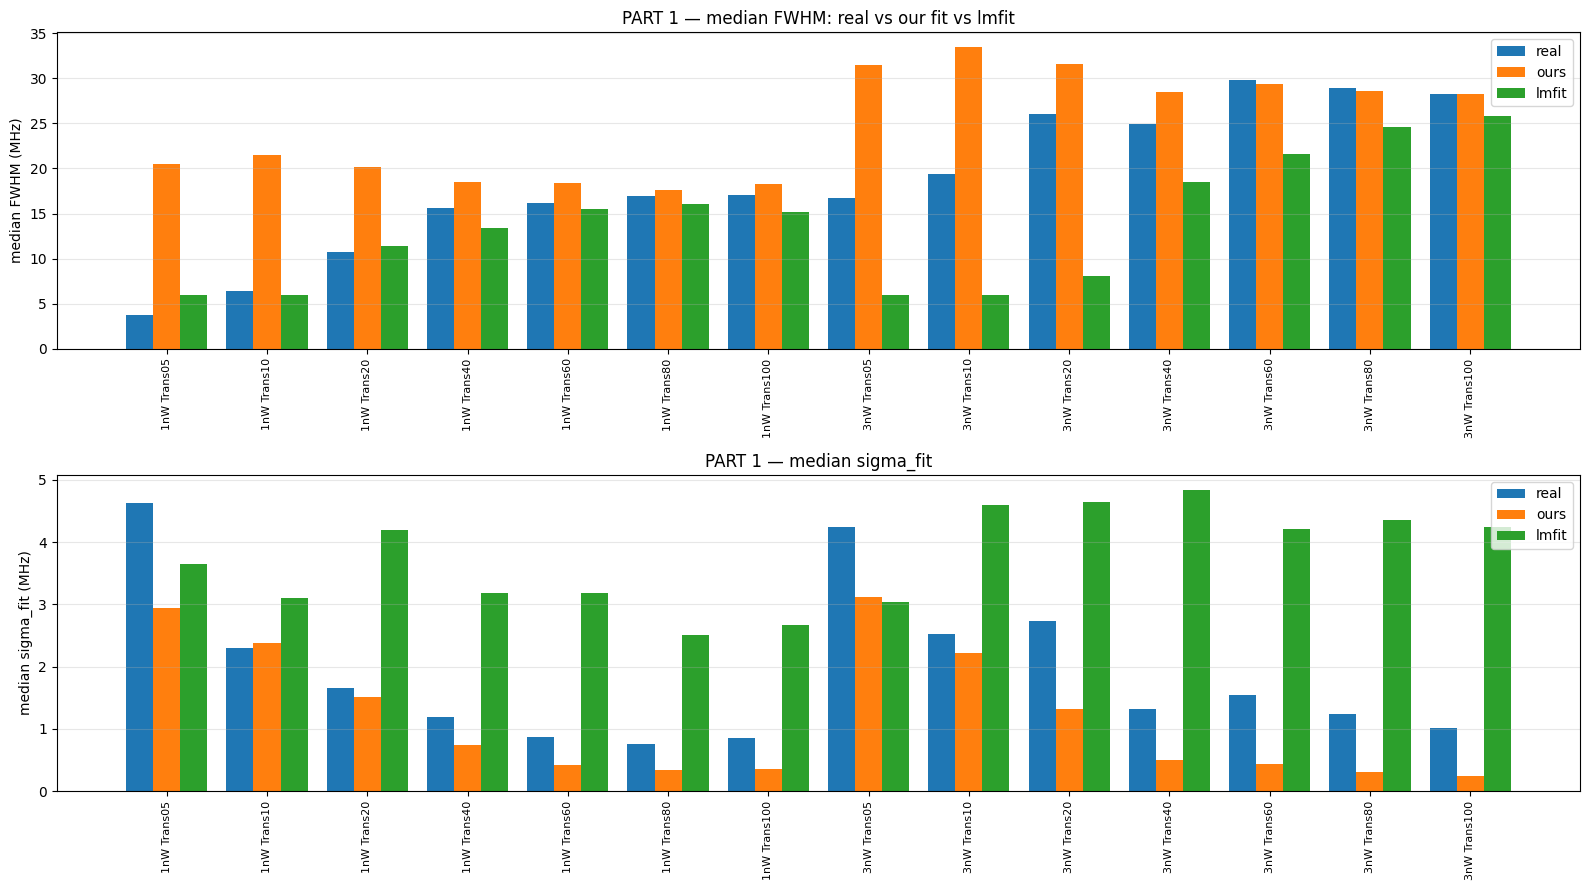

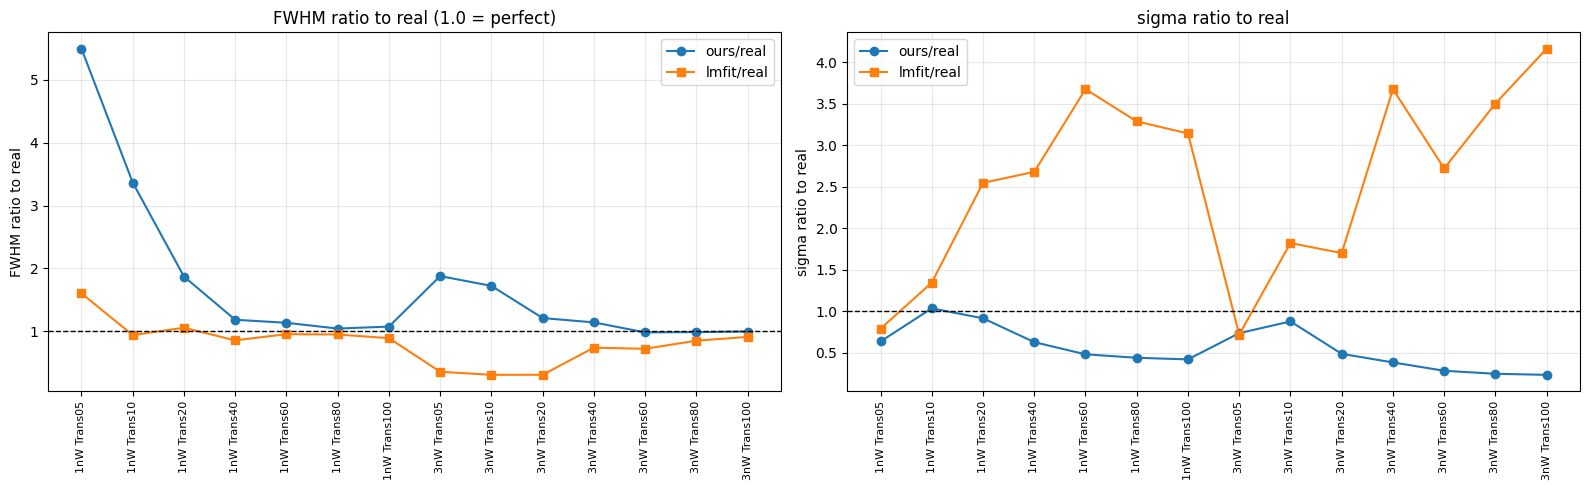

exp            realF    ourF     lmF |   realS    ourS     lmS |  lmOK
1nW Trans05     3.74   20.55    6.00 |    4.63    2.94    3.65 |    11
1nW Trans10     6.38   21.46    6.00 |    2.30    2.38    3.09 |    17
1nW Trans20    10.78   20.18   11.41 |    1.65    1.51    4.20 |    27
1nW Trans40    15.57   18.44   13.34 |    1.19    0.75    3.19 |    40
1nW Trans60    16.17   18.38   15.46 |    0.86    0.42    3.18 |    40
1nW Trans80    16.90   17.65   16.07 |    0.76    0.33    2.51 |    40
1nW Trans100   17.01   18.31   15.17 |    0.85    0.36    2.67 |    40
3nW Trans05    16.74   31.45    6.00 |    4.24    3.12    3.04 |    12
3nW Trans10    19.41   33.44    6.00 |    2.52    2.21    4.60 |    30
3nW Trans20    26.04   31.55    8.09 |    2.73    1.33    4.64 |    37
3nW Trans40    24.97   28.54   18.51 |    1.32    0.50    4.84 |    40
3nW Trans60    29.86   29.38   21.59 |    1.55    0.44    4.21 |    40
3nW Trans80    28.88   28.55   24.62 |    1.24    0.30    4.35 |    40
3nW Tr

In [5]:
# ============================================================
# PART 1 — observables: real vs sim-ours vs sim-lmfit  (per experiment)
# ============================================================
from scipy.stats import ks_2samp

def real_cols(e):
    d = np.genfromtxt(e['data_file'])
    f = d[:, 0] * 1000.0; s = d[:, 1] * 1000.0
    ok = ~np.isnan(f) & ~np.isnan(s) & (f > 0)
    r = s / np.where(f > 0, f, np.nan)
    filt = ok & (r < 10.0) & ~np.isnan(r)
    return f[filt], s[filt]

rows = []
for e in EXPERIMENTS:
    fr, sr = real_cols(e)
    rng = np.random.default_rng(2024)
    oF, oS, lF, lS = [], [], [], []
    for _ in range(N_SIM):
        u, b, ph = make_scan(e['gamma_true'], e['mu_true'], e['sigma_prop'], e['lam'], rng)
        Ff, Sf, _, _ = compute_fwhm_and_dgamma(e['gamma_true'], u, b, _fit_fn, _fwhm_fn, _nll_fn, n_params=2)
        oF.append(Ff); oS.append(Sf)
        lf, ls = lmfit_extract(ph.numpy())
        if lf is not None: lF.append(lf)
        if ls is not None: lS.append(ls)
    rows.append(dict(exp=e['name'], T=int(e['name'].split('Trans')[1]), power=e['power'],
                     realF=float(np.median(fr)), realS=float(np.median(sr)),
                     ourF=float(np.median(oF)), ourS=float(np.median(oS)),
                     lmF=float(np.median(lF)) if lF else np.nan,
                     lmS=float(np.median(lS)) if lS else np.nan,
                     n_ok_lm=len(lF), n_sim=N_SIM))

names = [r['exp'] for r in rows]; x = np.arange(len(rows))
fig, axes = plt.subplots(2, 1, figsize=(16, 9))
w = 0.27
for ax, key, lab in [(axes[0], 'F', 'median FWHM (MHz)'), (axes[1], 'S', 'median sigma_fit (MHz)')]:
    ax.bar(x - w, [r['real' + key] for r in rows], w, label='real')
    ax.bar(x,      [r['our' + key] for r in rows], w, label='ours')
    ax.bar(x + w,  [r['lm' + key] for r in rows], w, label='lmfit')
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=90, fontsize=8)
    ax.set_ylabel(lab); ax.grid(alpha=0.3, axis='y'); ax.legend()
axes[0].set_title('PART 1 — median FWHM: real vs our fit vs lmfit'); axes[1].set_title('PART 1 — median sigma_fit')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, key, lab in [(axes[0], 'F', 'FWHM ratio to real'), (axes[1], 'S', 'sigma ratio to real')]:
    ax.plot(x, [r['our' + key] / r['real' + key] for r in rows], 'o-', label='ours/real')
    ax.plot(x, [r['lm' + key] / r['real' + key] for r in rows], 's-', label='lmfit/real')
    ax.axhline(1.0, color='k', ls='--', lw=1)
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=90, fontsize=8)
    ax.set_ylabel(lab); ax.grid(alpha=0.3); ax.legend()
axes[0].set_title('FWHM ratio to real (1.0 = perfect)'); axes[1].set_title('sigma ratio to real')
plt.tight_layout(); plt.show()

print(f"{'exp':<12} {'realF':>7} {'ourF':>7} {'lmF':>7} | {'realS':>7} {'ourS':>7} {'lmS':>7} | {'lmOK':>5}")
for r in rows:
    print(f"{r['exp']:<12} {r['realF']:>7.2f} {r['ourF']:>7.2f} {r['lmF']:>7.2f} | "
          f"{r['realS']:>7.2f} {r['ourS']:>7.2f} {r['lmS']:>7.2f} | {r['n_ok_lm']:>5}")


timing on experiment 3nW Trans05 (30 scans):
  ours   (fit + implicit-diff derivatives) :     36.3 ms/scan
  lmfit  (bin + least-squares Voigt+const) :      9.4 ms/scan   (fits ok: 8/30)
  ratio lmfit/ours = 0.26x


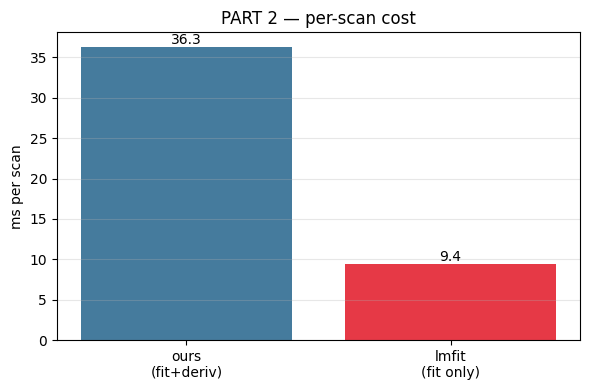

In [6]:
# ============================================================
# PART 2 — TIMING (head-to-head, per scan)
# ============================================================
import time as _t
e = EXPERIMENTS[min(len(EXPERIMENTS)//2, len(EXPERIMENTS)-1)]
rng = np.random.default_rng(7)
scans = [make_scan(e['gamma_true'], e['mu_true'], e['sigma_prop'], e['lam'], rng) for _ in range(TIMING_K)]

# per-scan timings
t0 = _t.perf_counter()
for u, b, ph in scans:
    _ = compute_fwhm_and_dgamma(e['gamma_true'], u, b, _fit_fn, _fwhm_fn, _nll_fn, n_params=2)
t_ours = (_t.perf_counter() - t0) / len(scans) * 1000

t0 = _t.perf_counter(); n_ok = 0
for u, b, ph in scans:
    fw, se = lmfit_extract(ph.numpy())
    n_ok += (fw is not None)
t_lm = (_t.perf_counter() - t0) / len(scans) * 1000

print(f"timing on experiment {e['name']} ({len(scans)} scans):")
print(f"  ours   (fit + implicit-diff derivatives) : {t_ours:8.1f} ms/scan")
print(f"  lmfit  (bin + least-squares Voigt+const) : {t_lm:8.1f} ms/scan   (fits ok: {n_ok}/{len(scans)})")
print(f"  ratio lmfit/ours = {t_lm/t_ours:.2f}x")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['ours\n(fit+deriv)', 'lmfit\n(fit only)'], [t_ours, t_lm], color=['#457b9d', '#e63946'])
ax.set_ylabel('ms per scan'); ax.set_title('PART 2 — per-scan cost'); ax.grid(alpha=0.3, axis='y')
for i, v in enumerate([t_ours, t_lm]):
    ax.text(i, v, f'{v:.1f}', ha='center', va='bottom')
plt.tight_layout(); plt.show()


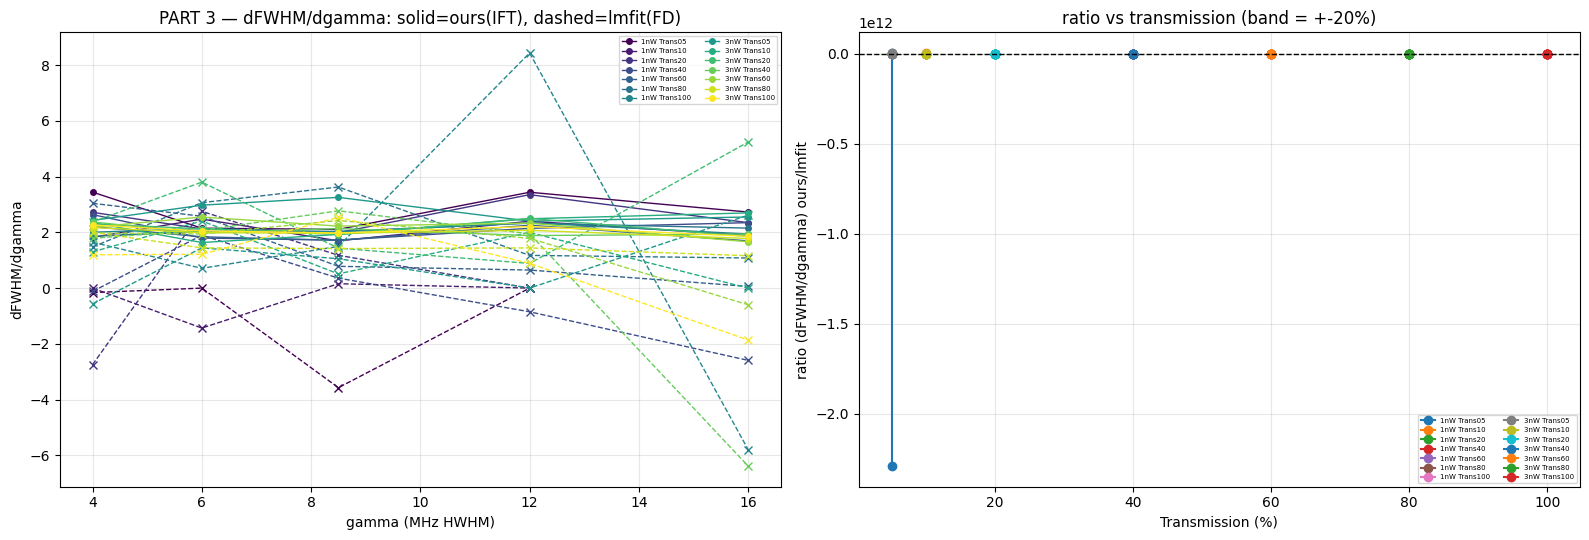

dFWHM/dgamma ratio ours/lmfit:  n=67  median=1.218  IQR=[0.560,1.988]  sign-consistent=False
dsigma/dgamma ratio ours/lmfit: n=67  median=0.068  sign-consistent=False
exp           gamma   df_our    df_lm   ratio |   ds_our    ds_lm
1nW Trans05     4.0    3.443   -0.161 -21.376 |   0.4818   0.2589
1nW Trans05     6.0    2.148    0.000 3343457426.675 |   0.2821   0.8760
1nW Trans05     8.5    2.106   -3.570  -0.590 |   0.3219  -3.0717
1nW Trans05    12.0    3.438   -0.000 -2290125198284.376 |   0.7536 262431.9663
1nW Trans05    16.0    2.728      nan     nan |   0.8045      nan
1nW Trans10     4.0    1.819   -0.000 -193398273.627 |   0.2144   0.5647
1nW Trans10     6.0    2.474   -1.433  -1.727 |   0.1265   0.0840
1nW Trans10     8.5    1.696    0.157  10.827 |   0.1920  -1.6347
1nW Trans10    12.0    2.398    0.000 1126103960.385 |   0.3889   0.2828
1nW Trans10    16.0    1.888      nan     nan |   0.4289      nan
1nW Trans20     4.0    2.718   -2.746  -0.990 |   0.2159   4.5578
1nW Tr

In [7]:
# ============================================================
# PART 3 — SURROGATE-GRADIENT VIABILITY
# dFWHM/dgamma (and d sigma/dgamma): ours (implicit diff) vs lmfit (finite difference), per exp x gamma
# ============================================================
sur = []
for e in EXPERIMENTS:
    for g in GAMMAS:
        T_ = int(e['name'].split('Trans')[1]); pw_ = 0 if e['power'] == '1nW' else 1
        rng = np.random.default_rng(100000 + pw_ * 50000 + T_ * 100 + int(g * 10))
        dfo, dso, Fp, Fm, Sp, Sm = [], [], [], [], [], []
        for _ in range(D_DRAWS):
            u, b, ph = make_scan(g, e['mu_true'], e['sigma_prop'], e['lam'], rng)
            _, _, dfo_, dso_ = compute_fwhm_and_dgamma(g, u, b, _fit_fn, _fwhm_fn, _nll_fn, n_params=2)
            dfo.append(dfo_); dso.append(dso_)
            gp = max(g + FD_H, 0.1); gm = max(g - FD_H, 0.1)
            php = build_photons(torch.tensor(gp), torch.as_tensor(u, dtype=torch.float32), torch.as_tensor(b, dtype=torch.float32))
            phm = build_photons(torch.tensor(gm), torch.as_tensor(u, dtype=torch.float32), torch.as_tensor(b, dtype=torch.float32))
            fp, sp = lmfit_extract(php.numpy()); fm, sm = lmfit_extract(phm.numpy())
            if fp is not None: Fp.append(fp)
            if fm is not None: Fm.append(fm)
            if sp is not None: Sp.append(sp)
            if sm is not None: Sm.append(sm)
        df_lm = (np.mean(Fp) - np.mean(Fm)) / (2 * FD_H) if (Fp and Fm) else np.nan
        ds_lm = (np.mean(Sp) - np.mean(Sm)) / (2 * FD_H) if (Sp and Sm) else np.nan
        sur.append(dict(exp=e['name'], T=int(e['name'].split('Trans')[1]), gamma=g,
                        df_our=float(np.mean(dfo)), ds_our=float(np.mean(dso)),
                        df_lm=df_lm, ds_lm=ds_lm))

Ts = sorted(set(r['T'] for r in sur))
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
cmap = plt.cm.viridis(np.linspace(0, 1, len(EXPERIMENTS)))
for ci, e in enumerate(EXPERIMENTS):
    sub = [r for r in sur if r['exp'] == e['name']]
    gs = [r['gamma'] for r in sub]
    axes[0].plot(gs, [r['df_our'] for r in sub], 'o-', color=cmap[ci], lw=1, ms=4, label=e['name'])
    axes[0].plot(gs, [r['df_lm'] for r in sub], 'x--', color=cmap[ci], lw=1, ms=6)
axes[0].set_xlabel('gamma (MHz HWHM)'); axes[0].set_ylabel('dFWHM/dgamma')
axes[0].set_title('PART 3 — dFWHM/dgamma: solid=ours(IFT), dashed=lmfit(FD)')
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=5, ncol=2)

# ratio vs transmission
for key, lab, ax in [('df', 'ratio (dFWHM/dgamma) ours/lmfit', axes[1])]:
    for e in EXPERIMENTS:
        sub = [r for r in sur if r['exp'] == e['name']]
        if not sub: continue
        ax.plot([r['T'] for r in sub], [r[key + '_our'] / r[key + '_lm'] if r[key + '_lm'] else np.nan for r in sub], 'o-', label=e['name'])
    ax.axhline(1.0, color='k', ls='--', lw=1); ax.axhspan(0.8, 1.2, color='green', alpha=0.08)
    ax.set_xlabel('Transmission (%)'); ax.set_ylabel(lab); ax.set_title('ratio vs transmission (band = +-20%)')
    ax.grid(alpha=0.3); ax.legend(fontsize=5, ncol=2)
plt.tight_layout(); plt.show()

ratios = [r['df_our'] / r['df_lm'] for r in sur if r['df_lm'] not in (0, None) and np.isfinite(r['df_lm'])]
ratios = [x for x in ratios if np.isfinite(x)]
print(f"dFWHM/dgamma ratio ours/lmfit:  n={len(ratios)}  median={np.median(ratios):.3f}  "
      f"IQR=[{np.percentile(ratios,25):.3f},{np.percentile(ratios,75):.3f}]  "
      f"sign-consistent={all(x>0 for x in ratios)}")
try:
    sr_ = [r['ds_our'] / r['ds_lm'] for r in sur if r['ds_lm'] not in (0, None) and np.isfinite(r['ds_lm'])]
    sr_ = [x for x in sr_ if np.isfinite(x)]
    print(f"dsigma/dgamma ratio ours/lmfit: n={len(sr_)}  median={np.median(sr_):.3f}  "
          f"sign-consistent={all(x>0 for x in sr_)}")
except Exception as _e:
    print('sigma-ratio error:', _e)

print(f"{'exp':<12} {'gamma':>6} {'df_our':>8} {'df_lm':>8} {'ratio':>7} | {'ds_our':>8} {'ds_lm':>8}")
for r in sur:
    rr = r['df_our'] / r['df_lm'] if r['df_lm'] else np.nan
    print(f"{r['exp']:<12} {r['gamma']:>6.1f} {r['df_our']:>8.3f} {r['df_lm']:>8.3f} {rr:>7.3f} | "
          f"{r['ds_our']:>8.4f} {r['ds_lm']:>8.4f}")


## Verdict template (fill after reading)
- **Observables:** does lmfit reproduce the real FWHM/sigma better than our fit (Part 1 ratios)?
- **Timing:** lmfit/ours per-scan cost.
- **Surrogate:** is the ratio ours/lmfit positive, ~constant, within +-20% across gamma and T?
  If yes -> surrogate viable (adopt lmfit forward + our implicit-diff gradient).
  If no -> need a differentiable binned-LSQ variant (Option C) or full FD (Option B).
